In [2]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
df1 = pd.read_csv('../ncbi_562_data.csv')
df2 = pd.read_csv('../ncbi_590_data.csv')


C:\Users\bryan\AppData\Local\Temp\ipykernel_12492\1438472862.py:6: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('../ncbi_590_data.csv')


In [3]:
df1 = df1[df1['is_usa_based'] == 1]
df1['collection_year'] = pd.to_numeric(df1['collection_year'], errors='coerce')
df1 = df1[df1['collection_year'] >= 1971]
df1 = df1[df1['month'].notna()]
df1['collection_year'] = df1['collection_year'].astype(str)
df1['collection_year'] = df1['collection_year'].str[:4]
df1['month'] = df1['month'].astype(int)
df1['month'] = df1['month'].apply(lambda x: f"{x:02d}")
df1['year_and_month'] = df1['collection_year'] + '-' + df1['month']

df2 = df2[df2['is_usa_based'] == 1]
df2['collection_year'] = pd.to_numeric(df2['collection_year'], errors='coerce')
df2 = df2[df2['collection_year'] >= 1971]
df2 = df2[df2['month'].notna()]
df2['collection_year'] = df2['collection_year'].astype(str)
df2['collection_year'] = df2['collection_year'].str[:4]
df2['month'] = df2['month'].astype(int)
df2['month'] = df2['month'].apply(lambda x: f"{x:02d}")
df2['year_and_month'] = df2['collection_year'] + '-' + df2['month']

In [4]:
year_month_counts1 = df1['year_and_month'].value_counts().sort_index()
#add counts of 0 for each month of each year where there is no count
for i in range(1, 13):
    for j in range(1974, 2024):
        year_month = f"{j}-{i:02d}"
        if year_month not in year_month_counts1.index:
            year_month_counts1[year_month] = 0
year_month_counts1 = year_month_counts1.sort_index()
year_month_counts2 = df2['year_and_month'].value_counts().sort_index()
for i in range(1, 13):
    for j in range(1974, 2024):
        year_month = f"{j}-{i:02d}"
        if year_month not in year_month_counts2.index:
            year_month_counts2[year_month] = 0
year_month_counts2 = year_month_counts2.sort_index()




In [5]:
#Make a sum of counts where the last three characters are -01 as January, -02 for February, etc.
monthly_counts1 = year_month_counts1.groupby(year_month_counts1.index.str[-2:]).sum()
monthly_counts2 = year_month_counts2.groupby(year_month_counts2.index.str[-2:]).sum()


In [6]:
#Replace 01 with Jan, 02 with Feb, etc
monthly_counts1.index = monthly_counts1.index.str.replace('01', 'Jan')
monthly_counts1.index = monthly_counts1.index.str.replace('02', 'Feb')
monthly_counts1.index = monthly_counts1.index.str.replace('03', 'Mar')
monthly_counts1.index = monthly_counts1.index.str.replace('04', 'Apr')
monthly_counts1.index = monthly_counts1.index.str.replace('05', 'May')
monthly_counts1.index = monthly_counts1.index.str.replace('06', 'Jun')
monthly_counts1.index = monthly_counts1.index.str.replace('07', 'Jul')
monthly_counts1.index = monthly_counts1.index.str.replace('08', 'Aug')
monthly_counts1.index = monthly_counts1.index.str.replace('09', 'Sep')
monthly_counts1.index = monthly_counts1.index.str.replace('10', 'Oct')
monthly_counts1.index = monthly_counts1.index.str.replace('11', 'Nov')
monthly_counts1.index = monthly_counts1.index.str.replace('12', 'Dec')

monthly_counts2.index = monthly_counts2.index.str.replace('01', 'Jan')
monthly_counts2.index = monthly_counts2.index.str.replace('02', 'Feb')
monthly_counts2.index = monthly_counts2.index.str.replace('03', 'Mar')
monthly_counts2.index = monthly_counts2.index.str.replace('04', 'Apr')
monthly_counts2.index = monthly_counts2.index.str.replace('05', 'May')
monthly_counts2.index = monthly_counts2.index.str.replace('06', 'Jun')
monthly_counts2.index = monthly_counts2.index.str.replace('07', 'Jul')
monthly_counts2.index = monthly_counts2.index.str.replace('08', 'Aug')
monthly_counts2.index = monthly_counts2.index.str.replace('09', 'Sep')
monthly_counts2.index = monthly_counts2.index.str.replace('10', 'Oct')
monthly_counts2.index = monthly_counts2.index.str.replace('11', 'Nov')
monthly_counts2.index = monthly_counts2.index.str.replace('12', 'Dec')


In [7]:
monthly_counts1

year_and_month
Jan    5282
Feb    4143
Mar    4567
Apr    4882
May    6114
Jun    7553
Jul    8733
Aug    8296
Sep    6665
Oct    6392
Nov    5370
Dec    4117
Name: count, dtype: int64

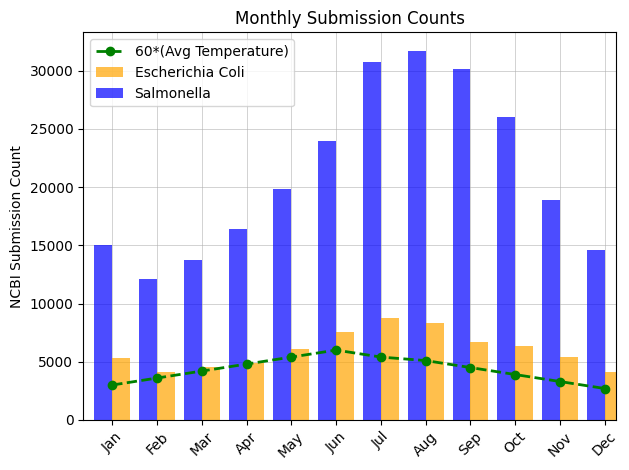

<Figure size 640x480 with 0 Axes>

In [ ]:
#Make a bar chart displaying monthly_counts1 and monthly_counts2

monthly_counts1.plot(kind='bar', color='orange', alpha=0.7, position=0, width=0.4)
monthly_counts2.plot(kind='bar', color='blue', alpha=0.7, position=1, width=0.4)
monthly_avg_temps = [60*50, 60*60, 60*70, 60*80, 60*90, 60*100, 60*90, 60*85, 60*75, 60*65, 60*55, 60*45]
# Add average monthly temperatures to the plot as a dashed line
plt.plot(monthly_avg_temps, marker='o', color='green', linestyle='--', linewidth=2)
plt.title('Monthly Submission Counts')
plt.xlabel('')
plt.ylabel('NCBI Submission Count')
plt.xticks(rotation=45)
plt.legend(['60*(Avg Temperature)', 'Escherichia Coli','Salmonella'])
plt.grid(linewidth=0.4)
plt.gca().set_axisbelow(True)
plt.tight_layout()
plt.show()
plt.savefig('submissions_by_month_562_590.png', dpi=300, bbox_inches='tight')